<a href="https://colab.research.google.com/github/tmedeirosb/tsi-am/blob/main/MODULO_03_AM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regressão: prevendo valores numéricos

Nesta demonstração a gente sai do conceito e vai para o código. O objetivo é prático:

1. Treinar uma **Regressão Linear** e um **KNN para regressão** com scikit-learn.
2. Avaliar os dois com **MAE, MSE, RMSE, R² e MAPE** e entender o que cada métrica diz.
3. Diagnosticar visualmente o modelo (**predito vs real**, **resíduos**, **QQ-plot**).

> Lembre da aula: a Regressão Linear ajusta uma reta que erra o mínimo possível. O KNN
> prevê pela **média dos k vizinhos mais próximos**. O KNN é o nosso *termômetro*:
> se ele bater o seu modelo, tem algo errado no modelo elaborado.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import scipy.stats as stats

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

## 2. Os dados

Vamos prever o **preço de um imóvel** (em centenas de milhares de R$) a partir de algumas
features. Para a aula rodar sem depender de internet, geramos um dataset **sintético**
porém realista: o preço cresce com a área e com a renda do bairro, cai com a idade do
imóvel, e tem um pouco de ruído — mais alguns **outliers** de propósito, para a gente ver
como cada métrica reage a eles.

In [2]:
rng = np.random.default_rng(42)
n = 1000

area      = rng.normal(90, 30, n).clip(30, 250)      # m2
idade     = rng.integers(0, 50, n)                   # anos
quartos   = rng.integers(1, 5, n)                    # numero de quartos
renda     = rng.normal(5, 2, n).clip(1, 12)          # renda media do bairro (mil R$)
dist_centro = rng.normal(8, 4, n).clip(0.5, 25)      # distancia ao centro (km)

# Preco "verdadeiro" + ruido. Coeficientes inventados, mas plausiveis.
preco = (1.2*area/50 + 1.5*renda - 0.8*idade/50
         + 0.6*quartos - 0.3*dist_centro
         + rng.normal(0, 1.0, n))

# Injeta alguns outliers (imoveis de luxo fora do padrao)
idx = rng.choice(n, 15, replace=False)
preco[idx] += rng.normal(8, 2, 15)

X = pd.DataFrame({"area": area, "idade": idade, "quartos": quartos,
                  "renda_bairro": renda, "dist_centro": dist_centro})
y = pd.Series(preco.clip(0.5, None), name="preco")

print("Formato de X:", X.shape)
print("Features:", list(X.columns))
X.head()

Formato de X: (1000, 5)
Features: ['area', 'idade', 'quartos', 'renda_bairro', 'dist_centro']


,area,idade,quartos,renda_bairro,dist_centro
0,99.141512,9,2,5.781450,10.562916
1,58.800477,32,2,6.090647,14.509605
2,112.513536,20,1,5.463321,7.763831
3,118.216941,17,4,6.930341,17.560891
4,31.468944,34,3,5.175735,6.058415


In [3]:
# Separar treino e teste: treinamos em uma parte e avaliamos no que o modelo NUNCA viu.
# É isso que dá uma estimativa honesta de desempenho.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Treino:", X_train.shape[0], "amostras  |  Teste:", X_test.shape[0], "amostras")

Treino: 800 amostras  |  Teste: 200 amostras


## 3. Modelo 1 — Regressão Linear

A regressão linear procura os **coeficientes** (pesos) que, multiplicados pelas features,
chegam o mais perto possível do valor real. Colocamos um `StandardScaler` antes para
deixar todas as features na mesma escala — isso ajuda na interpretação dos coeficientes
e é essencial para o KNN logo adiante.

In [4]:
lin = make_pipeline(StandardScaler(), LinearRegression())
lin.fit(X_train, y_train)

pred_lin = lin.predict(X_test)
print("Treinou. Primeiras 5 previsões:", np.round(pred_lin[:5], 2))

Treinou. Primeiras 5 previsões: [14.43  7.09  5.62  2.28  7.92]


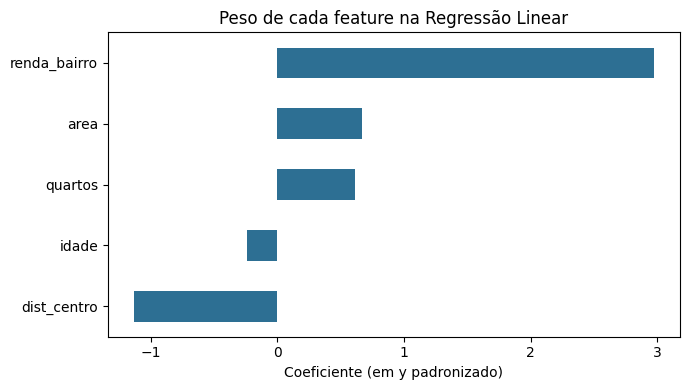

In [5]:
# O que o modelo aprendeu? Cada coeficiente diz o quanto aquela feature "puxa" o preço.
# (Como padronizamos, os coeficientes ficam comparaveis entre si.)
coefs = pd.Series(
    lin.named_steps["linearregression"].coef_,
    index=X.columns
).sort_values()

coefs.plot(kind="barh", color="#2D6F93")
plt.title("Peso de cada feature na Regressão Linear")
plt.xlabel("Coeficiente (em y padronizado)")
plt.tight_layout()
plt.show()

## 4. Modelo 2 — KNN para regressão

A ideia mais simples possível: para prever uma casa nova, o KNN olha as **k casas mais
parecidas** que ele já viu e devolve a **média** do preço delas. Não há fórmula treinada —
ele só "consulta os vizinhos". Por isso a padronização das features é obrigatória aqui:
distância só faz sentido se todas as features estiverem na mesma escala.

In [6]:
knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=10))
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)
print("Treinou. Primeiras 5 previsões:", np.round(pred_knn[:5], 2))

Treinou. Primeiras 5 previsões: [13.3   7.46  6.8   5.16  8.88]


## 5. Avaliação — as métricas, uma a uma

Vamos calcular tudo para os dois modelos e ler o que cada número significa.

- **MAE** — erro médio absoluto, na unidade de y. Fácil de explicar para o cliente.
- **MSE** — erro quadrático médio; penaliza erros grandes (eleva ao quadrado).
- **RMSE** — raiz do MSE; traz a interpretação de volta para a unidade de y.
- **R²** — compara com o "chute da média": 1 = perfeito, 0 = igual à média, negativo = pior.
- **MAPE** — erro percentual médio; bom para falar em %, mas estoura quando y ≈ 0.

In [7]:
def mape(y_true, y_pred):
    # erro percentual medio; cuidado: explode quando y_true e proximo de zero
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def avalia(nome, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mp = mape(y_true, y_pred)
    return {"Modelo": nome, "MAE": mae, "MSE": mse,
            "RMSE": rmse, "R2": r2, "MAPE(%)": mp}

tabela = pd.DataFrame([
    avalia("Regressao Linear", y_test, pred_lin),
    avalia("KNN (k=10)",       y_test, pred_knn),
]).set_index("Modelo").round(3)

tabela

,MAE,MSE,RMSE,R2,MAPE(%)
Modelo,,,,,
Regressao Linear,1.018,2.920,1.709,0.772,13.191
KNN (k=10),1.310,3.798,1.949,0.703,19.862


**Como ler a tabela acima (em sala):**
- Compare o **RMSE** e o **MAE** do mesmo modelo. Se o RMSE for bem maior que o MAE, é
  sinal de que existem **alguns erros grandes** puxando o resultado (outliers).
- O **R²** diz se o modelo é melhor que simplesmente chutar a média de y.
- Se o **KNN** estiver perto ou melhor que a Linear, vale investigar o modelo linear.

## 6. Diagnóstico visual

Número em tabela esconde problema. Três gráficos contam a história de verdade.

### 6.1. Predito vs Real
O ideal é os pontos colarem na diagonal. Desvios sistemáticos mostram onde o modelo erra.

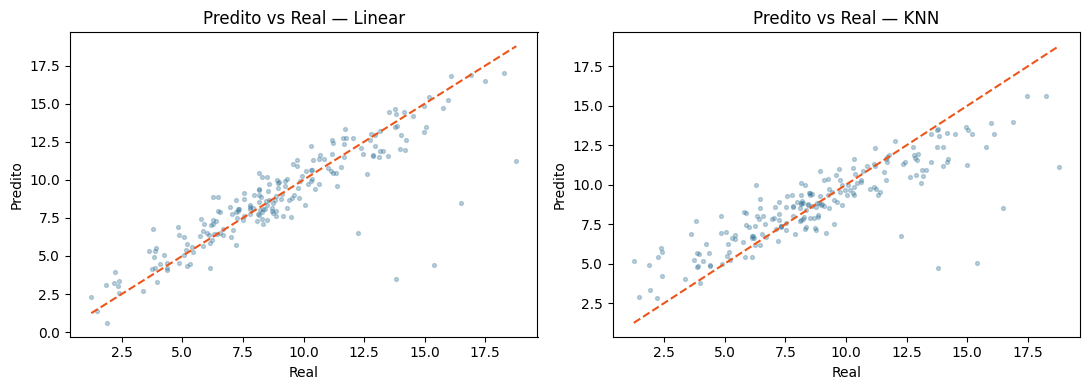

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(11, 4))
for ax, pred, nome in zip(axs, [pred_lin, pred_knn], ["Linear", "KNN"]):
    ax.scatter(y_test, pred, s=8, alpha=0.3, color="#2D6F93")
    lims = [y_test.min(), y_test.max()]
    ax.plot(lims, lims, "--", color="#ED561B")  # diagonal ideal
    ax.set_xlabel("Real"); ax.set_ylabel("Predito"); ax.set_title(f"Predito vs Real — {nome}")
plt.tight_layout(); plt.show()

### 6.2. Distribuição dos resíduos
O resíduo é o erro: `real - predito`. Queremos que fique **centrado em zero** e mais ou
menos **simétrico**. Uma cauda pesada ou um deslocamento indica viés do modelo.

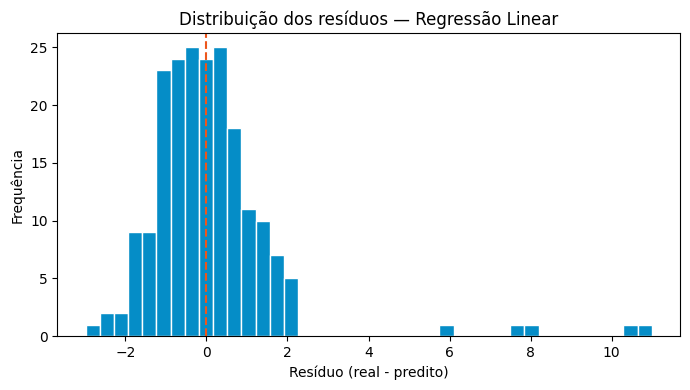

In [9]:
res_lin = y_test - pred_lin
plt.hist(res_lin, bins=40, color="#058DC7", edgecolor="white")
plt.axvline(0, color="#ED561B", linestyle="--")
plt.title("Distribuição dos resíduos — Regressão Linear")
plt.xlabel("Resíduo (real - predito)"); plt.ylabel("Frequência")
plt.tight_layout(); plt.show()

### 6.3. QQ-plot dos resíduos (normalidade)
Uma hipótese importante da regressão linear é que **o erro se distribui de forma normal**.
O QQ-plot compara os resíduos com uma normal teórica: se os pontos seguem a reta, a
suposição se sustenta; se fogem nas pontas, há erros extremos (outliers) que a regressão
linear não está dando conta.

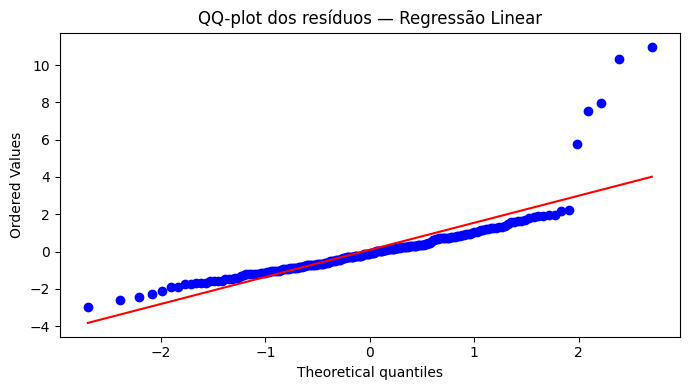

In [10]:
stats.probplot(res_lin, dist="norm", plot=plt)
plt.title("QQ-plot dos resíduos — Regressão Linear")
plt.tight_layout(); plt.show()

### 6.4. Multicolinearidade (features que andam juntas)
Quando duas features carregam quase a mesma informação, os coeficientes da regressão
linear ficam **instáveis e difíceis de interpretar**. Uma checagem rápida é a matriz de
correlação entre as features.

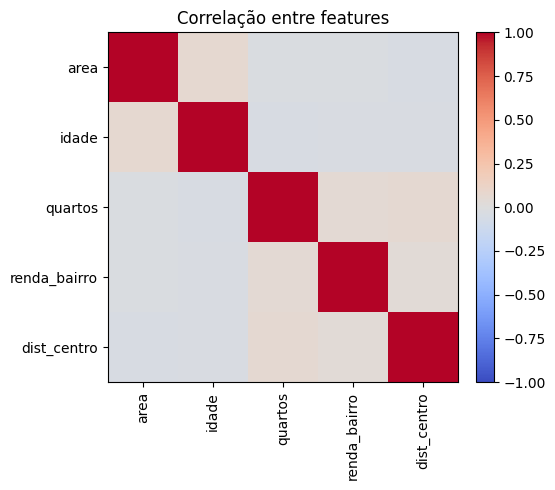

Pares com |correlacao| > 0.7:


In [11]:
corr = X_train.corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlação entre features")
plt.tight_layout(); plt.show()

# Pares com correlacao alta merecem atencao (possivel multicolinearidade)
alta = (corr.abs() > 0.7) & (corr.abs() < 1.0)
print("Pares com |correlacao| > 0.7:")
for col in corr.columns:
    for lin_ in corr.index:
        if alta.loc[lin_, col] and lin_ < col:
            print(f"  {lin_} x {col}: {corr.loc[lin_, col]:.2f}")

## 7. Escolhendo a métrica — é decisão de negócio

Não existe "a melhor métrica". A pergunta é: **o que dói mais no problema real?**
- Se errar muito em poucos casos é grave (ex.: precificar um imóvel caríssimo) → **RMSE**,
  porque ele pune erros grandes.
- Se todos os erros pesam igual e você quer explicar fácil → **MAE**.
- Se a conversa é em percentual → **MAPE**, lembrando que ele engana quando y ≈ 0.